In [1]:
!pip -q install sacrebleu nltk sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 5.8 MB/s eta 0:00:00


In [2]:
import os
import re
import math
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sacrebleu

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.11.0+cu128


In [3]:
ARABIC_DIACRITICS = re.compile(
    r'[\u064B-\u065F\u0670\u06D6-\u06ED]'
)


def normalize_arabic(text):

    text = text.strip()

    text = ARABIC_DIACRITICS.sub('', text)

    text = text.replace('أ', 'ا')
    text = text.replace('إ', 'ا')
    text = text.replace('آ', 'ا')
    text = text.replace('ى', 'ي')
    text = text.replace('ة', 'ه')
    text = text.replace('ـ', '')

    text = re.sub(
        r'([.!?؟،,])',
        r' \1 ',
        text
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text


def normalize_english(text):

    text = text.lower().strip()

    text = re.sub(
        r"([.!?,])",
        r' \1 ',
        text
    )

    text = re.sub(
        r"[^a-z0-9.!?,'\s]",
        '',
        text
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text


def tokenize(text):
    return text.split()

In [4]:
!pip -q install opustools

import subprocess

SRC_LANG = "en"
TGT_LANG = "ar"

print(f"--- Downloading Tatoeba ({SRC_LANG}-{TGT_LANG}) ---")

subprocess.run([
    "opus_read",
    "-d", "Tatoeba",
    "-s", SRC_LANG,
    "-t", TGT_LANG,
    "-w", f"Tatoeba.{SRC_LANG}-{TGT_LANG}.{SRC_LANG}",
          f"Tatoeba.{SRC_LANG}-{TGT_LANG}.{TGT_LANG}",
    "-wm", "moses",
    "-q"
])


def load_pairs_from_opus(en_path, ar_path):

    pairs = []

    with open(en_path, "r", encoding="utf-8") as f_en, \
         open(ar_path, "r", encoding="utf-8") as f_ar:

        for en_line, ar_line in zip(f_en, f_ar):

            en = normalize_english(en_line.strip())
            ar = normalize_arabic(ar_line.strip())

            if ar and en:
                pairs.append((ar, en))

    return pairs


pairs = load_pairs_from_opus(
    f"Tatoeba.{SRC_LANG}-{TGT_LANG}.{SRC_LANG}",
    f"Tatoeba.{SRC_LANG}-{TGT_LANG}.{TGT_LANG}"
)

print(f"Total samples loaded: {len(pairs):,}")

print("\nExamples:")
for ar, en in pairs[:3]:
    print("AR :", ar)
    print("EN :", en)
    print()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.7 MB/s eta 0:00:00
--- Downloading Tatoeba (en-ar) ---
Total samples loaded: 32,505

Examples:
AR : لنجرب فعل شيء ما .
EN : let 's try something .

AR : لنجرب شيئا !
EN : let 's try something .

AR : علي ان انام .
EN : i have to go to sleep .



In [5]:
def iqr_bounds(values, k=1.5):
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


def filter_outliers_by_length(pairs):

    ar_lens = np.array([len(tokenize(ar)) for ar, en in pairs])
    en_lens = np.array([len(tokenize(en)) for ar, en in pairs])
    avg_lens = (ar_lens + en_lens) / 2

    low, high = iqr_bounds(avg_lens)
    low = max(low, 1)

    print(f"Average word count bounds: [{low:.1f}, {high:.1f}]  (raw range: {avg_lens.min():.1f}-{avg_lens.max():.1f})")

    kept, removed = [], 0

    for (ar, en), avg_l in zip(pairs, avg_lens):
        if low <= avg_l <= high:
            kept.append((ar, en))
        else:
            removed += 1

    print(f"Removed {removed:,} length-outlier pairs out of {len(pairs):,} ({removed / len(pairs):.1%})")

    return kept


def filter_outliers_by_ratio(pairs):

    ar_lens = np.array([len(tokenize(ar)) for ar, en in pairs])
    en_lens = np.array([len(tokenize(en)) for ar, en in pairs])
    ratio = en_lens / ar_lens

    low, high = iqr_bounds(ratio)

    print(f"EN/AR ratio bounds: [{low:.2f}, {high:.2f}]  (raw range: {ratio.min():.2f}-{ratio.max():.2f})")

    kept, removed = [], 0

    for (ar, en), r in zip(pairs, ratio):
        if low <= r <= high:
            kept.append((ar, en))
        else:
            removed += 1

    print(f"Removed {removed:,} ratio-outlier pairs out of {len(pairs):,} ({removed / len(pairs):.1%})")

    return kept


print(f"Before filtering: {len(pairs):,}")
pairs = filter_outliers_by_length(pairs)
pairs = filter_outliers_by_ratio(pairs)
print(f"After filtering : {len(pairs):,}")

Before filtering: 32,505
Average word count bounds: [1.0, 12.0]  (raw range: 1.5-207.0)
Removed 1,445 length-outlier pairs out of 32,505 (4.4%)
EN/AR ratio bounds: [0.25, 2.25]  (raw range: 0.33-14.00)
Removed 396 ratio-outlier pairs out of 31,060 (1.3%)
After filtering : 30,664


In [6]:
random.Random(SEED).shuffle(pairs)

n = len(pairs)

n_train = int(0.90 * n)
n_val   = int(0.05 * n)

train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:n_train + n_val]
test_pairs  = pairs[n_train + n_val:]

print(f"Train: {len(train_pairs):,}")
print(f"Val  : {len(val_pairs):,}")
print(f"Test : {len(test_pairs):,}")

Train: 27,597
Val  : 1,533
Test : 1,534


In [7]:
import sentencepiece as spm


class Vocab:
    """Thin wrapper around a trained SentencePiece BPE model, keeping the
    same PAD/SOS/EOS/UNK interface the rest of the notebook already used.

    Subword (BPE) tokenization instead of whitespace splitting is the single
    biggest lever for this dataset: Arabic is morphologically rich (a verb
    like "يكتب/كتب/كاتب/مكتوب" are all different surface forms of one root),
    so a word-level vocab wastes capacity on near-duplicate forms and turns
    any rare inflection straight into <unk>. BPE instead breaks unseen or
    rare words into familiar sub-word pieces, so the model almost never has
    to emit <unk> and can still generalize to inflections it never saw as a
    whole word during training.
    """

    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self, sp_model_path):
        self.sp = spm.SentencePieceProcessor(model_file=sp_model_path)

    def __len__(self):
        return self.sp.get_piece_size()

    def encode(self, text, add_sos=False, add_eos=True):
        ids = self.sp.encode(text, out_type=int)

        if add_sos:
            ids = [self.SOS] + ids

        if add_eos:
            ids = ids + [self.EOS]

        return ids

    def encode_pieces(self, text):
        """Raw BPE subword strings (used only for attention-plot axes)."""
        return self.sp.encode(text, out_type=str)

    def id_to_piece(self, idx):
        return self.sp.id_to_piece(idx)

    def decode(self, ids):
        clean = [i for i in ids if i not in (self.PAD, self.SOS, self.EOS)]
        return self.sp.decode(clean)

In [8]:
SP_DIR = "/content/spm"
os.makedirs(SP_DIR, exist_ok=True)

# Small/medium corpus -> keep the subword vocab modest. This also acts as a
# mild regularizer (fewer, more frequently-seen units) compared to letting
# SentencePiece chase a very large vocab on ~25k training sentences.
SRC_VOCAB_SIZE = 8000
TGT_VOCAB_SIZE = 8000


def write_corpus(path, sentences):
    with open(path, "w", encoding="utf-8") as f:
        for s in sentences:
            f.write(s + "\n")


def train_sentencepiece(corpus_path, model_prefix, vocab_size):
    spm.SentencePieceTrainer.Train(
        input=corpus_path,
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        model_type="bpe",
        character_coverage=1.0,
        pad_id=Vocab.PAD, bos_id=Vocab.SOS, eos_id=Vocab.EOS, unk_id=Vocab.UNK,
        pad_piece="<pad>", bos_piece="<sos>", eos_piece="<eos>", unk_piece="<unk>",
        # Don't hard-error if the corpus can't actually fill vocab_size
        # distinct pieces -- just use as many as it can.
        hard_vocab_limit=False,
    )


src_corpus_path = f"{SP_DIR}/src_corpus.txt"
tgt_corpus_path = f"{SP_DIR}/tgt_corpus.txt"

write_corpus(src_corpus_path, [ar for ar, _ in train_pairs])
write_corpus(tgt_corpus_path, [en for _, en in train_pairs])

train_sentencepiece(src_corpus_path, f"{SP_DIR}/src_spm", SRC_VOCAB_SIZE)
train_sentencepiece(tgt_corpus_path, f"{SP_DIR}/tgt_spm", TGT_VOCAB_SIZE)

src_vocab = Vocab(f"{SP_DIR}/src_spm.model")
tgt_vocab = Vocab(f"{SP_DIR}/tgt_spm.model")

print("Arabic BPE vocab :", len(src_vocab))
print("English BPE vocab:", len(tgt_vocab))

Arabic BPE vocab : 8000
English BPE vocab: 8000


In [9]:
WORK_DIR = "/content/nmt_project_transformer"
os.makedirs(WORK_DIR, exist_ok=True)


def save_pairs(path, data):

    with open(path, "w", encoding="utf-8") as f:

        for ar, en in data:
            f.write(ar + "\t" + en + "\n")


TRAIN_FILE = f"{WORK_DIR}/train.tsv"
VAL_FILE   = f"{WORK_DIR}/val.tsv"
TEST_FILE  = f"{WORK_DIR}/test.tsv"

save_pairs(TRAIN_FILE, train_pairs)
save_pairs(VAL_FILE, val_pairs)
save_pairs(TEST_FILE, test_pairs)

print("Splits saved.")

Splits saved.


In [10]:
class LazyNMTDataset(Dataset):

    def __init__(self, path, src_vocab, tgt_vocab):

        self.path = path
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

        self.offsets = []

        with open(path, "rb") as f:

            while True:

                pos = f.tell()
                line = f.readline()

                if not line:
                    break

                self.offsets.append(pos)

    def __len__(self):
        return len(self.offsets)

    def __getitem__(self, idx):

        with open(self.path, "rb") as f:

            f.seek(self.offsets[idx])
            line = f.readline().decode("utf-8").rstrip("\n")

        ar, en = line.split("\t")

        src_ids = self.src_vocab.encode(ar, add_sos=False, add_eos=True)
        tgt_ids = self.tgt_vocab.encode(en, add_sos=True, add_eos=True)

        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_ids, dtype=torch.long)
        )

In [11]:
def collate_fn(batch):
    """No more pack_padded_sequence / lengths needed here — the Transformer
    only cares about the padding mask, which we derive from Vocab.PAD directly
    inside the model."""

    src, tgt = zip(*batch)

    src = pad_sequence(src, batch_first=True, padding_value=Vocab.PAD)
    tgt = pad_sequence(tgt, batch_first=True, padding_value=Vocab.PAD)

    return src, tgt

In [12]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()

        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)

        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [13]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()

        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):

        B = query.size(0)

        Q = self.w_q(query).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(key).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(value).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        # Q, K, V: (B, n_heads, T, d_k)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # scores: (B, n_heads, T_q, T_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        context = torch.matmul(attn, V)  # (B, n_heads, T_q, d_k)
        context = context.transpose(1, 2).contiguous().view(B, -1, self.d_model)

        out = self.w_o(context)

        return out, attn

In [14]:
class PositionwiseFeedForward(nn.Module):

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(torch.relu(self.fc1(x))))

In [15]:
class EncoderLayer(nn.Module):

    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, src_mask):

        normed = self.norm1(x)
        attn_out, _ = self.self_attn(normed, normed, normed, src_mask)
        x = x + self.dropout1(attn_out)

        normed = self.norm2(x)
        ffn_out = self.ffn(normed)
        x = x + self.dropout2(ffn_out)

        return x

In [16]:
class DecoderLayer(nn.Module):

    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask, tgt_mask):

        normed = self.norm1(x)
        self_attn_out, _ = self.self_attn(normed, normed, normed, tgt_mask)
        x = x + self.dropout1(self_attn_out)

        normed = self.norm2(x)
        cross_attn_out, cross_attn_w = self.cross_attn(normed, enc_out, enc_out, src_mask)
        x = x + self.dropout2(cross_attn_out)

        normed = self.norm3(x)
        ffn_out = self.ffn(normed)
        x = x + self.dropout3(ffn_out)

        return x, cross_attn_w

In [17]:
class Encoder(nn.Module):

    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout=0.1, max_len=200):
        super().__init__()

        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=Vocab.PAD)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)

        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

    def forward(self, src, src_mask):

        x = self.embedding(src) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)

        for layer in self.layers:
            x = layer(x, src_mask)

        return self.norm(x)

In [18]:
class Decoder(nn.Module):

    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout=0.1,
                 max_len=200, tie_embeddings=True):
        super().__init__()

        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=Vocab.PAD)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)

        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.norm = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, vocab_size)

        if tie_embeddings:
            # target embedding and output projection share weights:
            # fewer parameters, and empirically a small quality bump on
            # small/medium NMT datasets.
            self.fc_out.weight = self.embedding.weight

    def forward(self, tgt, enc_out, src_mask, tgt_mask):

        x = self.embedding(tgt) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)

        cross_attn_w = None

        for layer in self.layers:
            x, cross_attn_w = layer(x, enc_out, src_mask, tgt_mask)

        x = self.norm(x)
        logits = self.fc_out(x)

        return logits, cross_attn_w

In [19]:
class Seq2SeqTransformer(nn.Module):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def make_src_mask(self, src):
        # (B, 1, 1, T_src) -> broadcasts over heads and query positions
        return (src != Vocab.PAD).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):

        B, T = tgt.shape

        pad_mask = (tgt != Vocab.PAD).unsqueeze(1).unsqueeze(2)          # (B, 1, 1, T)
        causal_mask = torch.tril(torch.ones((T, T), device=tgt.device)).bool()  # (T, T)

        return pad_mask & causal_mask  # (B, 1, T, T)

    def forward(self, src, tgt):

        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)

        enc_out = self.encoder(src, src_mask)
        logits, _ = self.decoder(tgt, enc_out, src_mask, tgt_mask)

        return logits

In [20]:
D_MODEL = 256
N_HEADS = 8
D_FF = 512
N_ENC_LAYERS = 3
N_DEC_LAYERS = 3
DROPOUT = 0.2
MAX_LEN = 100

encoder = Encoder(len(src_vocab), D_MODEL, N_HEADS, D_FF, N_ENC_LAYERS, DROPOUT, MAX_LEN)
decoder = Decoder(len(tgt_vocab), D_MODEL, N_HEADS, D_FF, N_DEC_LAYERS, DROPOUT, MAX_LEN)

model = Seq2SeqTransformer(encoder, decoder).to(device)

for p in model.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {params:,}")

Trainable parameters: 8,058,688


In [21]:
class NoamScheduler:
    """Wraps a torch optimizer and exposes step()/zero_grad() like a normal
    optimizer, but updates the LR itself before every step."""

    def __init__(self, optimizer, d_model, warmup_steps=4000, factor=1.0):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.factor = factor
        self.step_num = 0

    def step(self):
        self.step_num += 1
        lr = self.factor * (
            self.d_model ** (-0.5) *
            min(self.step_num ** (-0.5), self.step_num * self.warmup_steps ** (-1.5))
        )

        for group in self.optimizer.param_groups:
            group["lr"] = lr

        self.optimizer.step()

    def zero_grad(self):
        self.optimizer.zero_grad()

    def get_lr(self):
        return self.optimizer.param_groups[0]["lr"]


criterion = nn.CrossEntropyLoss(ignore_index=Vocab.PAD, label_smoothing=0.1)

base_optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=1e-4,   # was 0 -- L2-style regularization, standard with AdamW
)

optimizer = NoamScheduler(base_optimizer, d_model=D_MODEL, warmup_steps=3000)

EPOCHS = 50
CLIP = 1.0
PATIENCE = 5   # a bit more slack since we now early-stop on val BLEU, a
               # noisier metric epoch-to-epoch than val loss

In [22]:
def train_epoch(model, loader):

    model.train()
    total_loss = 0

    for src, tgt in tqdm(loader, desc="Train", leave=False):

        src = src.to(device, non_blocking=True)
        tgt = tgt.to(device, non_blocking=True)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        optimizer.zero_grad()

        logits = model(src, tgt_input)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader):

    model.eval()
    total_loss = 0

    for src, tgt in tqdm(loader, desc="Val", leave=False):

        src = src.to(device, non_blocking=True)
        tgt = tgt.to(device, non_blocking=True)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        logits = model(src, tgt_input)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        )

        total_loss += loss.item()

    return total_loss / len(loader)

In [23]:
BATCH_SIZE = 64

train_ds = LazyNMTDataset(TRAIN_FILE, src_vocab, tgt_vocab)
val_ds   = LazyNMTDataset(VAL_FILE, src_vocab, tgt_vocab)
test_ds  = LazyNMTDataset(TEST_FILE, src_vocab, tgt_vocab)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=0, pin_memory=True
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=0, pin_memory=True
)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=0, pin_memory=True
)

print("Train:", len(train_ds))
print("Val  :", len(val_ds))
print("Test :", len(test_ds))
print("Train batches:", len(train_loader))

Train: 27597
Val  : 1533
Test : 1534
Train batches: 432


In [24]:
def detokenize_en(text):
    """Undo the space-padding around punctuation added by normalize_english,
    so sacrebleu scores natural (not pre-tokenized) text as intended."""
    text = re.sub(r"\s+([.,!?'])", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


@torch.no_grad()
def quick_translate(model, ar_text, max_len=60):
    """Greedy decode without attention tracking -- used for fast per-epoch
    validation BLEU during training (checkpoint selection). BPE sequences
    run longer than word-level ones for the same sentence, hence max_len=60
    instead of the old max_len=30."""

    model.eval()

    text = normalize_arabic(ar_text)
    src_ids = src_vocab.encode(text, add_sos=False, add_eos=True)

    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_mask = model.make_src_mask(src)
    enc_out = model.encoder(src, src_mask)

    generated = [Vocab.SOS]

    for _ in range(max_len):

        tgt = torch.tensor([generated], dtype=torch.long, device=device)
        tgt_mask = model.make_tgt_mask(tgt)

        logits, _ = model.decoder(tgt, enc_out, src_mask, tgt_mask)
        pred = logits[0, -1].argmax(-1).item()

        if pred == Vocab.EOS:
            break

        generated.append(pred)

    return tgt_vocab.decode(generated[1:])


@torch.no_grad()
def quick_val_bleu(model, pairs_subset):
    model.eval()
    refs, hyps = [], []

    for ar, en in pairs_subset:
        hyps.append(detokenize_en(quick_translate(model, ar)))
        refs.append(detokenize_en(en))

    return sacrebleu.corpus_bleu(hyps, [refs]).score


# Fixed subset so the metric is comparable epoch-to-epoch.
_val_subset_rng = random.Random(SEED)
val_bleu_subset = val_pairs[:]
_val_subset_rng.shuffle(val_bleu_subset)
val_bleu_subset = val_bleu_subset[:min(300, len(val_bleu_subset))]

print(f"Using {len(val_bleu_subset)} validation sentences for per-epoch BLEU tracking.")

Using 300 validation sentences for per-epoch BLEU tracking.


In [25]:
history = {"train": [], "val": [], "val_bleu": []}

best_val_bleu = -1.0
bad_epochs = 0

for epoch in range(1, EPOCHS + 1):

    start = time.time()

    train_loss = train_epoch(model, train_loader)
    val_loss = evaluate_loss(model, val_loader)
    val_bleu = quick_val_bleu(model, val_bleu_subset)

    history["train"].append(train_loss)
    history["val"].append(val_loss)
    history["val_bleu"].append(val_bleu)

    lr = optimizer.get_lr()

    print(
        f"Epoch {epoch:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
        f"Val BLEU (subset): {val_bleu:.2f} | LR: {lr:.2e} | Time: {time.time()-start:.1f}s"
    )


    if val_bleu > best_val_bleu + 1e-3:

        best_val_bleu = val_bleu
        bad_epochs = 0

        torch.save(model.state_dict(), f"{WORK_DIR}/best_transformer.pt")

    else:

        bad_epochs += 1

        if bad_epochs >= PATIENCE:
            print("Early stopping.")
            break


model.load_state_dict(
    torch.load(f"{WORK_DIR}/best_transformer.pt", map_location=device)
)

print(f"Best validation BLEU (subset): {best_val_bleu:.2f}")

Train:   0%|          | 0/432 [00:00<?, ?it/s]

Val:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 01 | Train: 6.9194 | Val: 5.4800 | Val BLEU (subset): 0.11 | LR: 1.64e-04 | Time: 51.0s


Train:   0%|          | 0/432 [00:00<?, ?it/s]

Val:   0%|          | 0/24 [00:00<?, ?it/s]

...

Val:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 24 | Train: 2.1754 | Val: 3.1314 | Val BLEU (subset): 33.24 | LR: 6.14e-04 | Time: 25.7s


Train:   0%|          | 0/432 [00:00<?, ?it/s]

Val:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 25 | Train: 2.1529 | Val: 3.1332 | Val BLEU (subset): 31.61 | LR: 6.01e-04 | Time: 25.8s
Early stopping.
Best validation BLEU (subset): 33.53


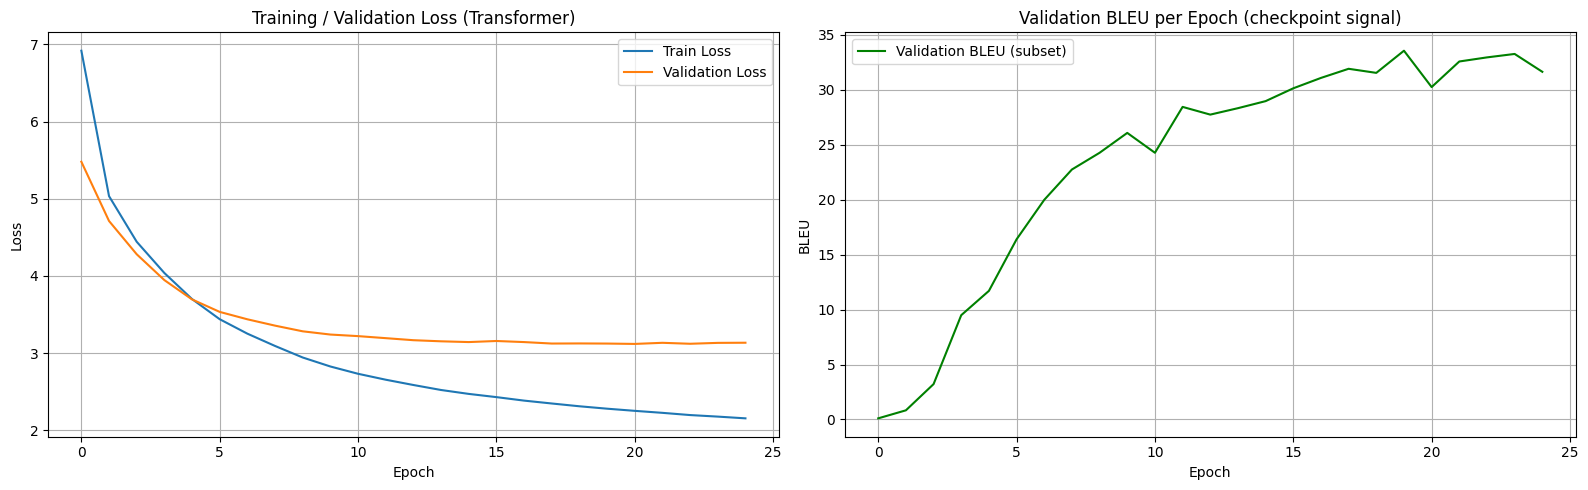

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history["train"], label="Train Loss")
axes[0].plot(history["val"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training / Validation Loss (Transformer)")
axes[0].legend()
axes[0].grid()

axes[1].plot(history["val_bleu"], label="Validation BLEU (subset)", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("BLEU")
axes[1].set_title("Validation BLEU per Epoch (checkpoint signal)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

In [27]:
@torch.no_grad()
def translate(model, arabic_sentence, max_len=60):
    """Greedy decoding over BPE subwords. Returns (translation,
    attention_matrix, src_pieces, generated_pieces): `translation` is the
    fully detokenized string, while src_pieces/generated_pieces are the raw
    BPE subword tokens used for the attention heatmap axes below."""

    model.eval()

    text = normalize_arabic(arabic_sentence)
    src_ids = src_vocab.encode(text, add_sos=False, add_eos=True)
    src_pieces = src_vocab.encode_pieces(text) + ["<eos>"]

    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_mask = model.make_src_mask(src)

    enc_out = model.encoder(src, src_mask)

    generated = [Vocab.SOS]
    generated_pieces = []
    attention_weights = []

    for _ in range(max_len):

        tgt = torch.tensor([generated], dtype=torch.long, device=device)
        tgt_mask = model.make_tgt_mask(tgt)

        logits, cross_attn = model.decoder(tgt, enc_out, src_mask, tgt_mask)

        pred = logits[0, -1].argmax(-1).item()

        if pred == Vocab.EOS:
            break

        generated.append(pred)
        generated_pieces.append(tgt_vocab.id_to_piece(pred))

        # cross_attn: (1, n_heads, T_tgt, T_src) -> attention of the last
        # decoder layer for the subword just generated, averaged over heads.
        step_attn = cross_attn[0, :, -1, :].mean(dim=0).cpu().numpy()
        attention_weights.append(step_attn)

    translation = tgt_vocab.decode(generated[1:])

    return translation, np.array(attention_weights), src_pieces, generated_pieces

In [28]:
def show_attention(arabic_sentence):

    translation, attention, src_pieces, tgt_pieces = translate(model, arabic_sentence)

    plt.figure(figsize=(12, 7))

    plt.imshow(attention, aspect="auto")

    # "▁" is SentencePiece's word-boundary marker; strip it for a cleaner axis.
    clean_src = [(p.replace("▁", "") or "▁") for p in src_pieces]
    fixed_tokens = [fix_arabic_display(tok) for tok in clean_src]
    plt.xticks(range(len(fixed_tokens)), fixed_tokens, rotation=45, ha="right")

    clean_tgt = [p.replace("▁", " ") for p in tgt_pieces]
    plt.yticks(range(len(clean_tgt)), clean_tgt)

    plt.xlabel("Arabic Source Subwords (BPE)")
    plt.ylabel("English Generated Subwords (BPE)")
    plt.title("Transformer Cross-Attention Weights (last layer, head-averaged)")

    plt.colorbar(label="Attention Weight")

    plt.tight_layout()
    plt.show()

    print("Arabic :", arabic_sentence)
    print("English:", translation)

In [29]:
@torch.no_grad()
def predict_dataset(model, dataset_path):

    references = []
    hypotheses = []

    with open(dataset_path, "r", encoding="utf-8") as f:

        for line in tqdm(f, desc="Translating Test Set"):

            ar, en = line.rstrip("\n").split("\t")

            prediction, _, _, _ = translate(model, ar)

            references.append(en)
            hypotheses.append(prediction)

    return references, hypotheses

In [30]:
references, hypotheses = predict_dataset(model, TEST_FILE)

references_detok = [detokenize_en(r) for r in references]
hypotheses_detok = [detokenize_en(h) for h in hypotheses]

bleu = sacrebleu.corpus_bleu(hypotheses_detok, [references_detok])

print(f"Test BLEU: {bleu.score:.2f}")

Translating Test Set: 0it [00:00, ?it/s]

Test BLEU: 33.62


In [31]:
@torch.no_grad()
def compute_bleu_on_loader(model, dataset_path):

    references = []
    hypotheses = []

    with open(dataset_path, "r", encoding="utf-8") as f:

        for line in tqdm(f, desc="Translating Validation Set"):

            ar, en = line.rstrip("\n").split("\t")

            prediction, _, _, _ = translate(model, ar)

            references.append(detokenize_en(en))
            hypotheses.append(detokenize_en(prediction))

    return sacrebleu.corpus_bleu(hypotheses, [references])


val_bleu = compute_bleu_on_loader(model, VAL_FILE)

print(f"Validation BLEU: {val_bleu.score:.2f}")

Translating Validation Set: 0it [00:00, ?it/s]

Validation BLEU: 32.73


## Error Analysis

Per-sentence BLEU على test set، مع فحص أسوأ الأمثلة عشان نلاقي أنماط الفشل المتكررة (truncation, repetition).

In [ ]:
@torch.no_grad()
def compute_sentence_bleu_table(model, dataset_path):

    rows = []

    with open(dataset_path, "r", encoding="utf-8") as f:

        for line in tqdm(f, desc="Scoring sentences"):

            ar, en = line.rstrip("\n").split("\t")

            prediction, _, _, _ = translate(model, ar)

            ref = detokenize_en(en)
            hyp = detokenize_en(prediction)

            score = sacrebleu.sentence_bleu(hyp, [ref]).score

            rows.append({
                "arabic": ar,
                "reference": ref,
                "prediction": hyp,
                "bleu": score,
                "ref_len": len(ref.split()),
                "pred_len": len(hyp.split())
            })

    return pd.DataFrame(rows)


error_df = compute_sentence_bleu_table(model, TEST_FILE)

worst = error_df.sort_values("bleu").head(15)

print("=== 15 Worst Translations (lowest sentence BLEU) ===\n")
for _, row in worst.iterrows():
    ar_ = row["arabic"]
    ref_ = row["reference"]
    hyp_ = row["prediction"]
    print(f"AR : {ar_}")
    print(f"REF: {ref_}")
    print(f"HYP: {hyp_}")
    print(f"BLEU: {row['bleu']:.2f} | ref_len={row['ref_len']} pred_len={row['pred_len']}")
    print()

In [33]:
def has_repetition(text, n=2):
    tokens = text.split()
    for i in range(len(tokens) - n):
        if tokens[i:i + n] == tokens[i + n:i + 2 * n]:
            return True
    return False


short_preds = (worst["pred_len"] < worst["ref_len"] * 0.5).sum()
repeated = worst["prediction"].apply(has_repetition).sum()

print("Out of the 15 worst test examples:")
print(f" - {short_preds} have predictions under half the reference length (possible truncation / early <eos>)")
print(f" - {repeated} contain a repeated word sequence (possible decoding loop)")
print()
print(f"Overall test BLEU        : {bleu.score:.2f}")
print(f"Mean sentence BLEU (all) : {error_df['bleu'].mean():.2f}")
print(f"Mean sentence BLEU (worst 15): {worst['bleu'].mean():.2f}")

Out of the 15 worst test examples:
 - 0 have predictions under half the reference length (possible truncation / early <eos>)
 - 0 contain a repeated word sequence (possible decoding loop)

Overall test BLEU        : 33.62
Mean sentence BLEU (all) : 37.87
Mean sentence BLEU (worst 15): 2.03


In [ ]:
@torch.no_grad()
def beam_search_translate(model, arabic_sentence, beam_width=5, max_len=60, length_penalty=0.7):
    """Unlike the RNN version, there's no per-beam hidden state to carry:
    the encoder output is computed once and shared by every beam, and each
    beam just re-runs the decoder over its own (short) sequence so far."""

    model.eval()

    text = normalize_arabic(arabic_sentence)
    src_ids = src_vocab.encode(text, add_sos=False, add_eos=True)

    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_mask = model.make_src_mask(src)

    enc_out = model.encoder(src, src_mask)

    beams = [([Vocab.SOS], 0.0)]
    completed = []

    for _ in range(max_len):

        candidates = []

        for seq, score in beams:

            if seq[-1] == Vocab.EOS:
                completed.append((seq, score))
                continue

            tgt = torch.tensor([seq], dtype=torch.long, device=device)
            tgt_mask = model.make_tgt_mask(tgt)

            logits, _ = model.decoder(tgt, enc_out, src_mask, tgt_mask)
            log_probs = torch.log_softmax(logits[0, -1], dim=-1)

            topk_log_probs, topk_ids = log_probs.topk(beam_width)

            for lp, idx in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                candidates.append((seq + [idx], score + lp))

        if not candidates:
            break

        candidates.sort(key=lambda b: b[1] / (len(b[0]) ** length_penalty), reverse=True)
        beams = candidates[:beam_width]

        if all(seq[-1] == Vocab.EOS for seq, _ in beams):
            completed.extend(beams)
            break

    if not completed:
        completed = beams

    best_seq, _ = max(completed, key=lambda x: x[1] / (len(x[0]) ** length_penalty))
    generated = [t for t in best_seq if t not in (Vocab.SOS, Vocab.EOS)]

    return tgt_vocab.decode(generated)

In [35]:
@torch.no_grad()
def evaluate_beam_search_bleu(model, dataset_path, beam_width=5):

    references = []
    hypotheses = []

    with open(dataset_path, "r", encoding="utf-8") as f:
        for line in tqdm(f, desc="Beam Search Translating"):
            ar, en = line.rstrip("\n").split("\t")
            prediction = beam_search_translate(model, ar, beam_width=beam_width)

            references.append(detokenize_en(en))
            hypotheses.append(detokenize_en(prediction))

    return sacrebleu.corpus_bleu(hypotheses, [references])


beam_bleu = evaluate_beam_search_bleu(model, TEST_FILE, beam_width=5)

print(f"Test BLEU (beam search, width=5): {beam_bleu.score:.2f}")
print(f"Test BLEU (greedy, from earlier): {bleu.score:.2f}")

Beam Search Translating: 0it [00:00, ?it/s]

Test BLEU (beam search, width=5): 35.19
Test BLEU (greedy, from earlier): 33.62


In [ ]:
!pip -q install arabic_reshaper python-bidi

import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic_display(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

In [ ]:
# Attention weight visualization for a few sample sentences
sample_sentences = [
    "لقد رفض ان يدفع ؟",
    "طمع الانسان يهدد حياه كثير من الانواع الحيه .",
    "القانون والسياسه هما شيئان مختلفان .",
]

for sent in sample_sentences:
    show_attention(sent)

In [ ]:
best = error_df.sort_values("bleu", ascending=False).head(10)

print("=== Top 10 Best Translations (highest sentence BLEU) ===\n")
for _, row in best.iterrows():
    ar_ = row["arabic"]
    ref_ = row["reference"]
    hyp_ = row["prediction"]
    print(f"AR : {ar_}")
    print(f"REF: {ref_}")
    print(f"HYP: {hyp_}")
    print(f"BLEU: {row['bleu']:.2f} | ref_len={row['ref_len']} pred_len={row['pred_len']}")
    print()

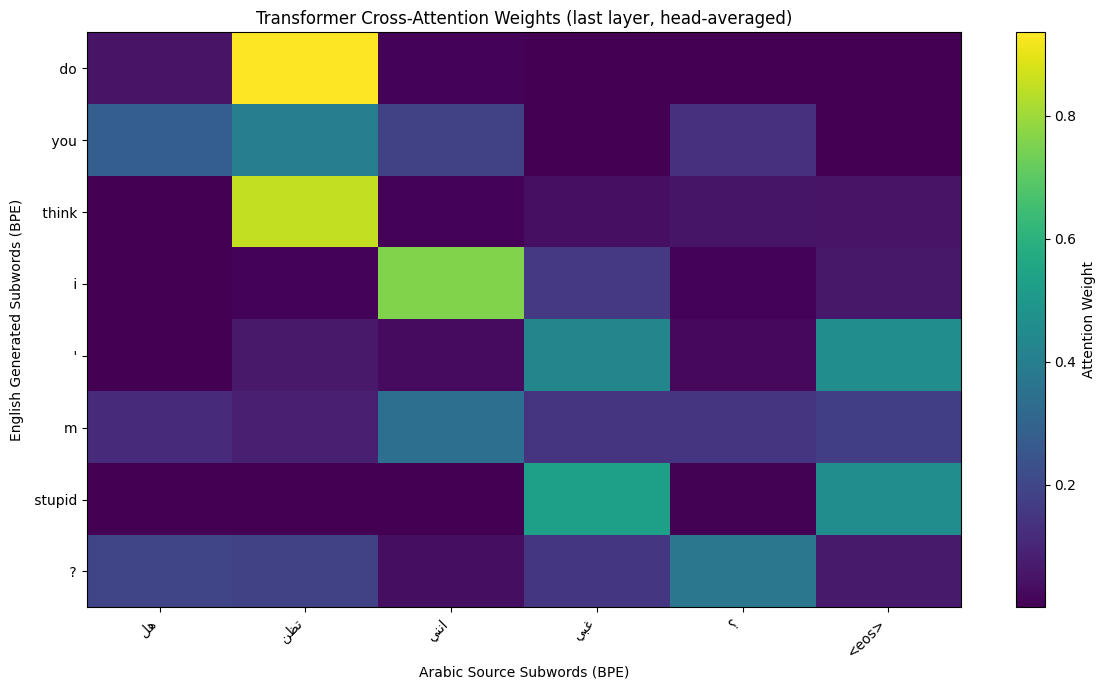

Arabic : هل تظن انني غبي ؟
English: do you think i 'm stupid ?


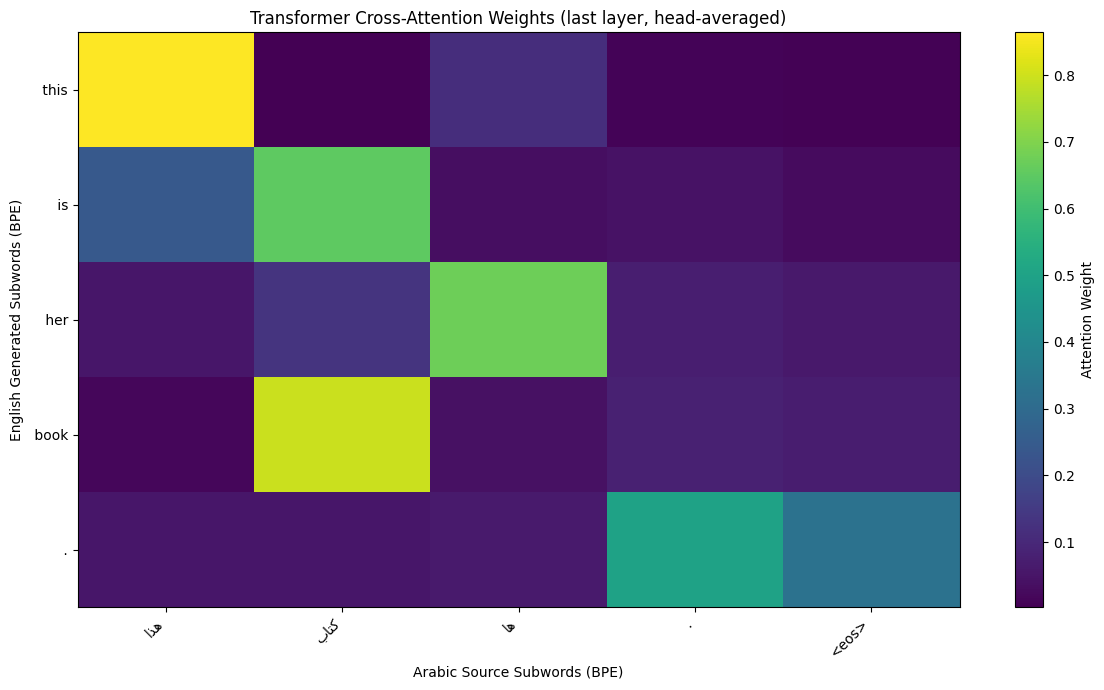

Arabic : هذا كتابها .
English: this is her book .


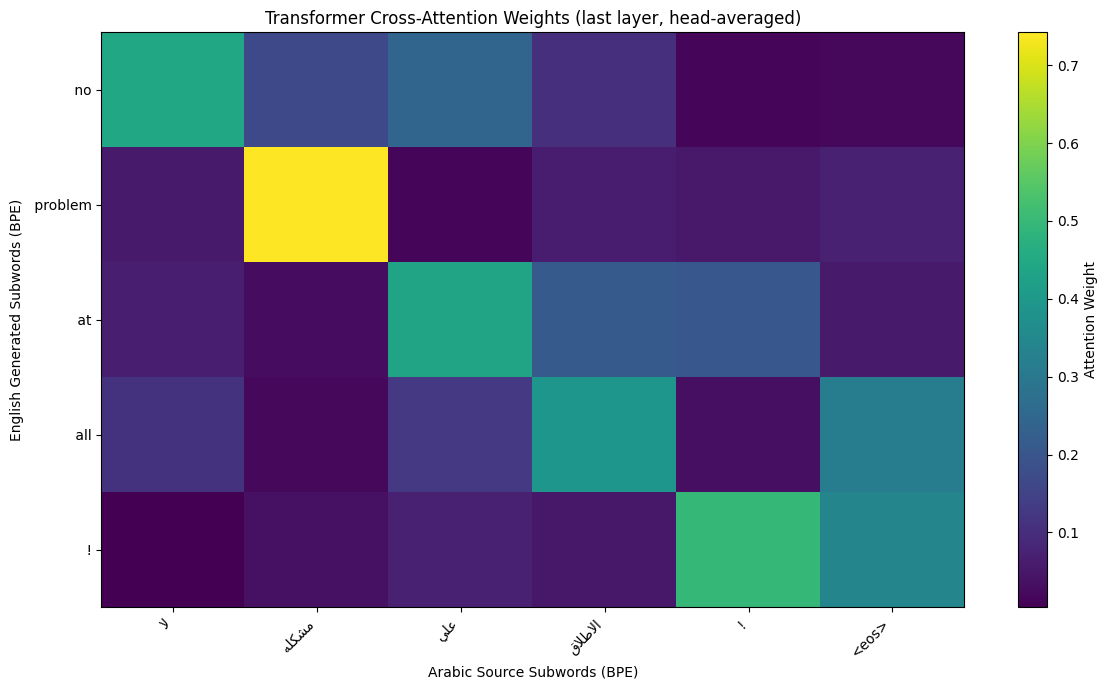

Arabic : لا مشكله علي الاطلاق !
English: no problem at all !


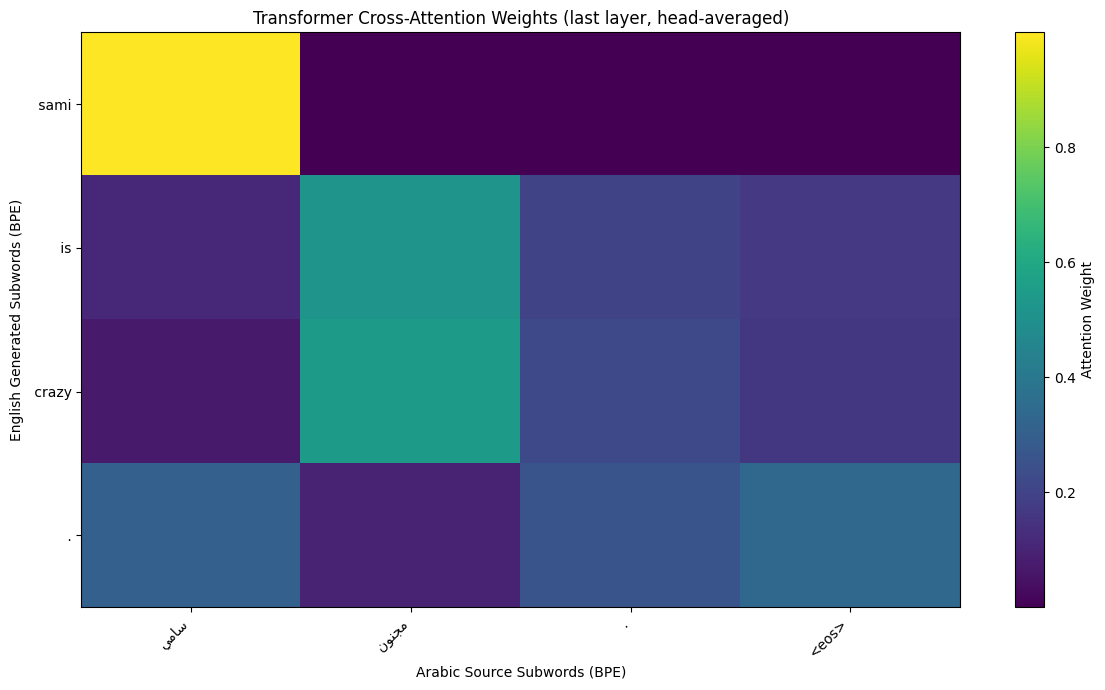

Arabic : سامي مجنون .
English: sami is crazy .


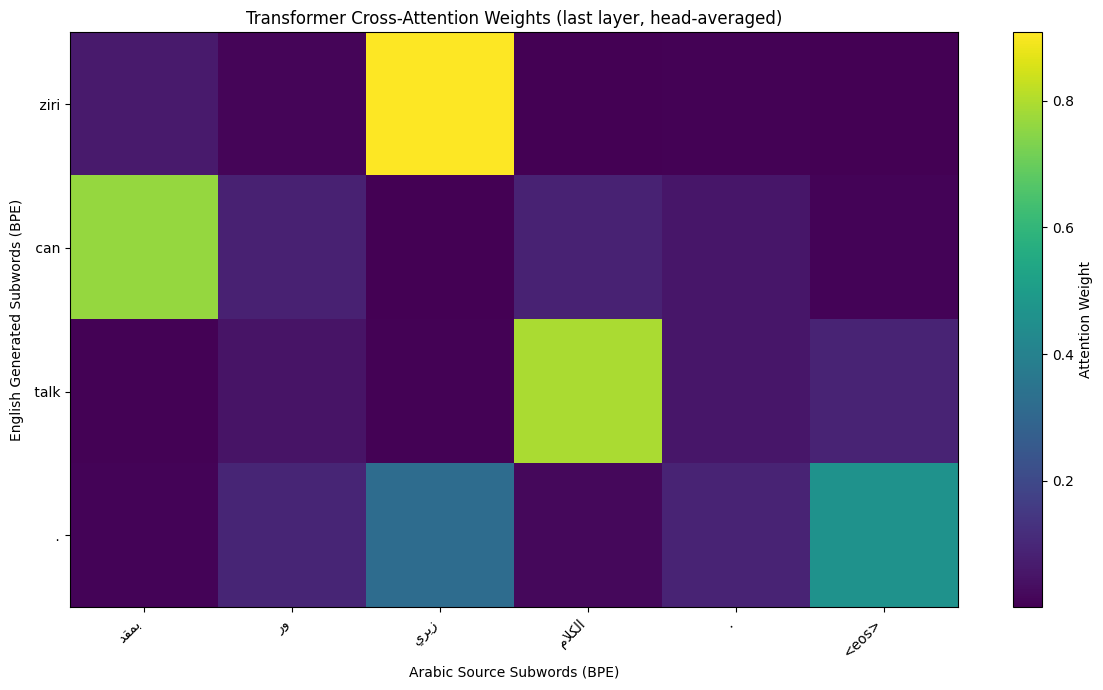

Arabic : بمقدور زيري الكلام .
English: ziri can talk .


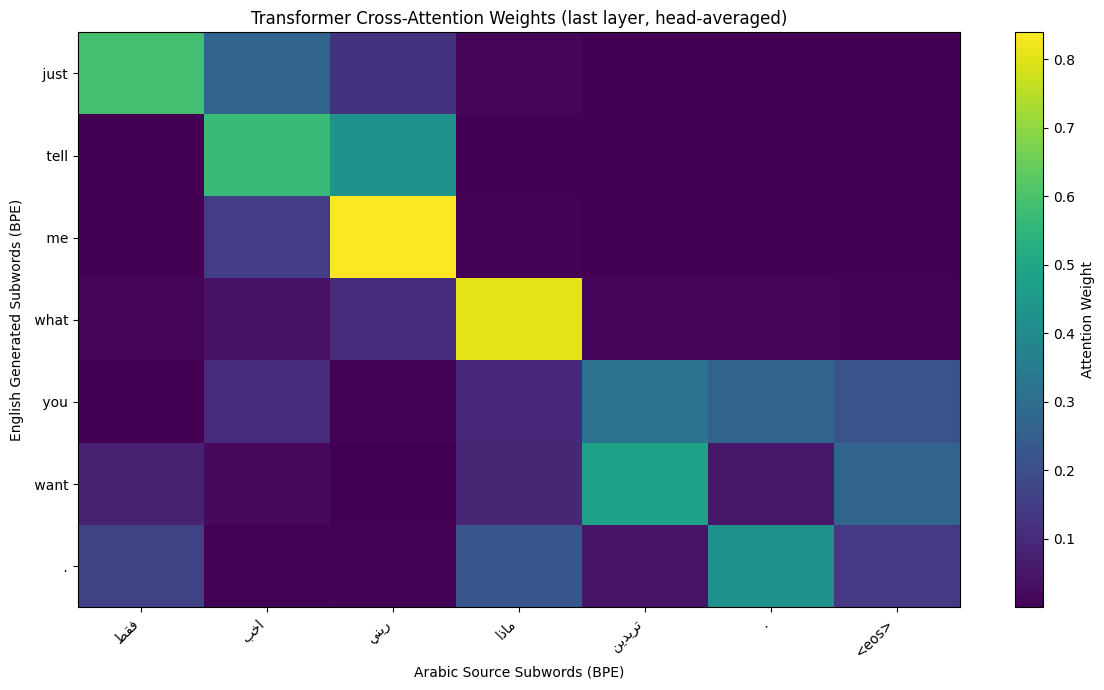

Arabic : فقط اخبريني ماذا تريدين .
English: just tell me what you want .


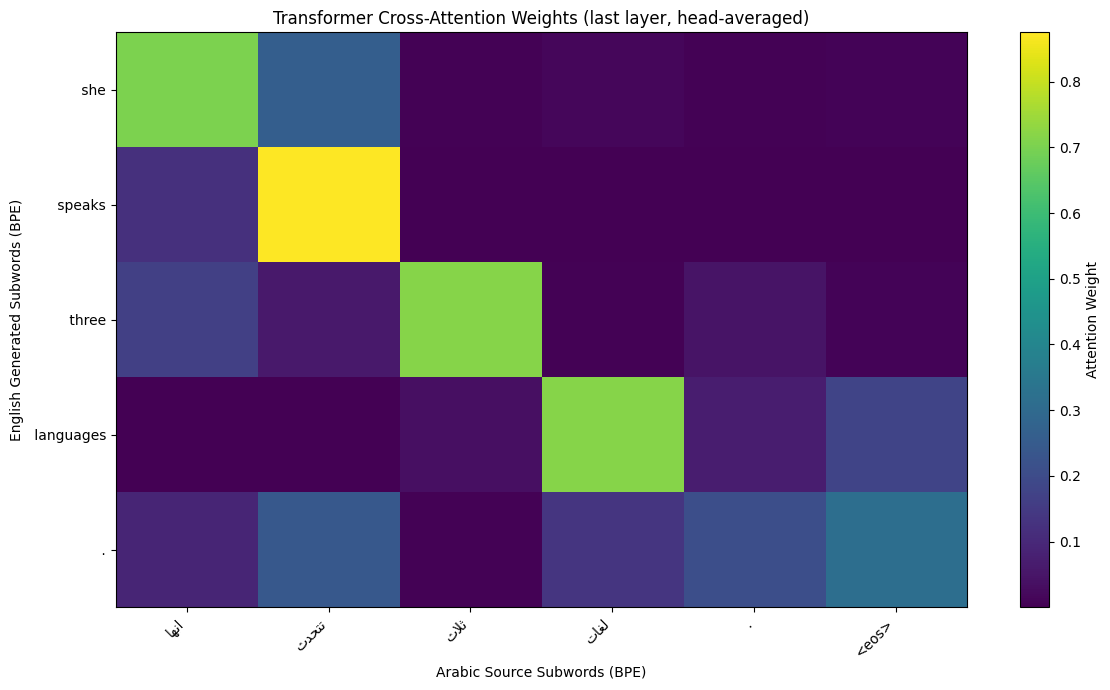

Arabic : انها تتحدث ثلاث لغات .
English: she speaks three languages .


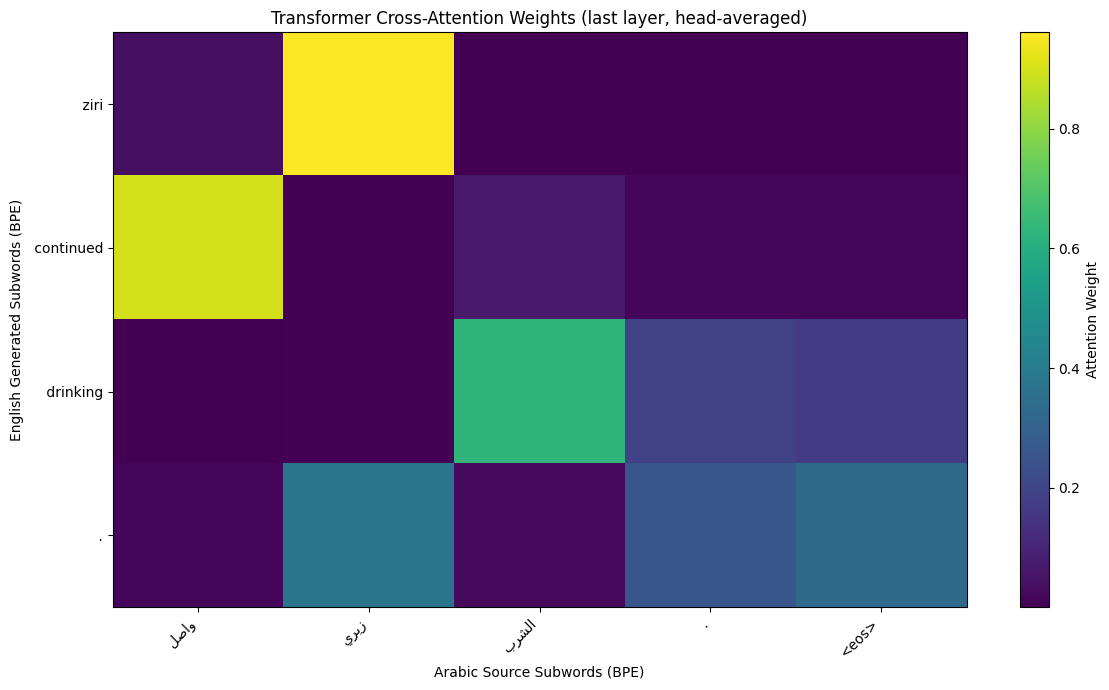

Arabic : واصل زيري الشرب .
English: ziri continued drinking .


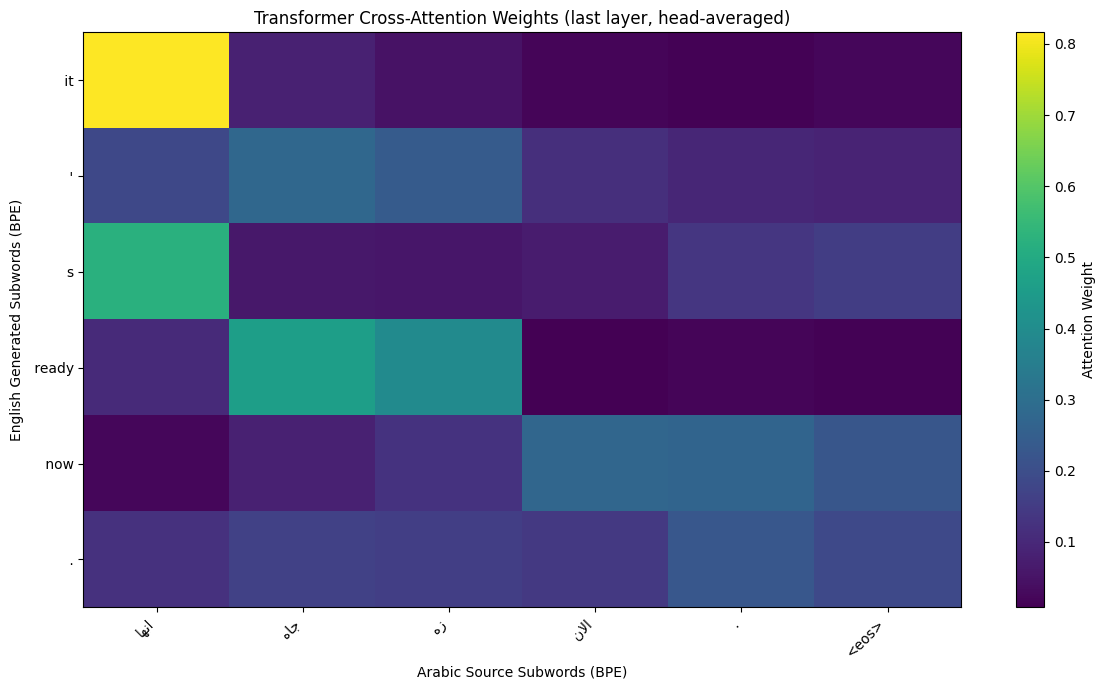

Arabic : انها جاهزه الان .
English: it 's ready now .


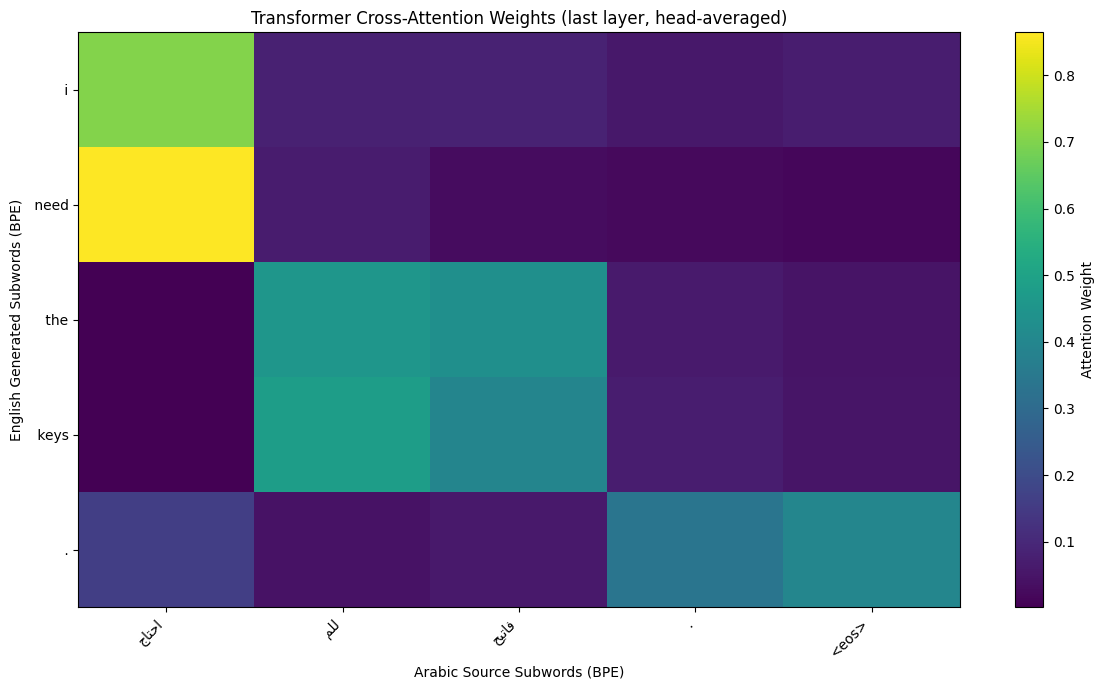

Arabic : احتاج للمفاتيح .
English: i need the keys .


In [39]:
for sent in best["arabic"]:
    show_attention(sent)